In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
from PIL import Image 
import torch

In [9]:
# load the feature and label images 
features = torch.load("/home/ssalhi/scratch/cifar10_data/features.pt", weights_only=False)
labels   = torch.load("/home/ssalhi/scratch/cifar10_data/labels.pt",   weights_only=False)
train_images = torch.load("/home/ssalhi/scratch/cifar10_data/train_images.pt", weights_only=False).squeeze()

features = torch.as_tensor(features).contiguous()
labels   = torch.as_tensor(labels).contiguous()
train_images = torch.as_tensor(train_images).contiguous()
N = features.shape[0]

# uncompress
features = features.reshape(N, 16, 16, 3)
labels = labels.reshape(N, 16, 16, 3)

print(features.shape, labels.shape, train_images.shape)

torch.Size([50000, 16, 16, 3]) torch.Size([50000, 16, 16, 3]) torch.Size([50000, 32, 32, 3])


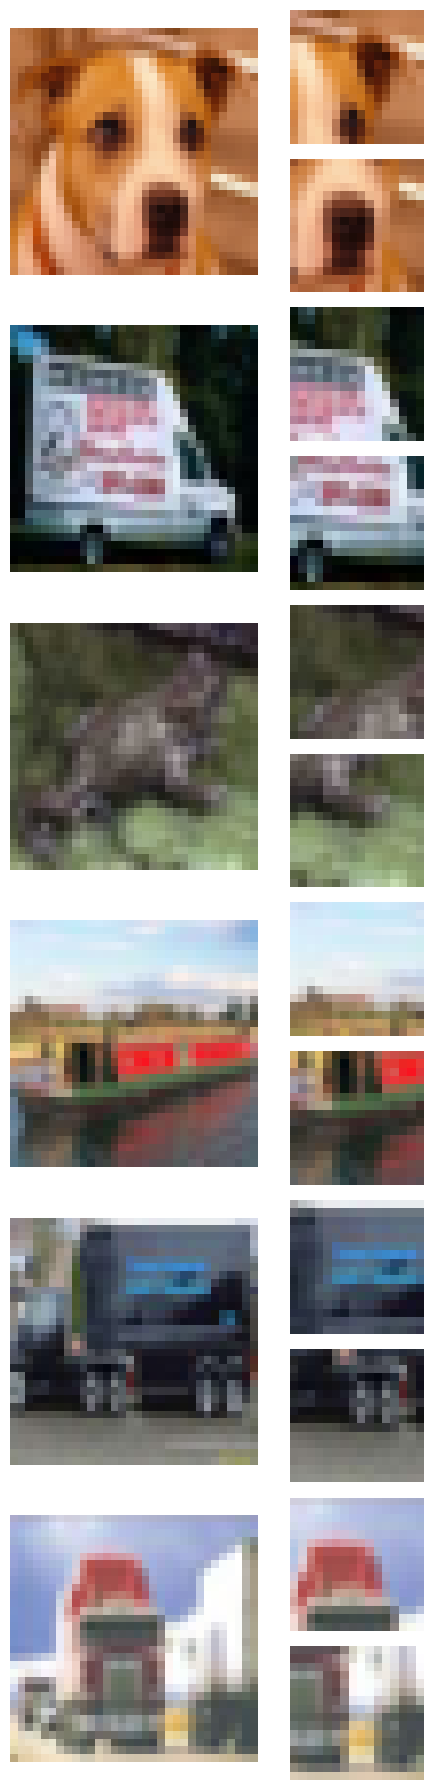

In [16]:
num_examples = 6
N = features.shape[0]
num_examples = min(num_examples, N)

# random unique indices from the full dataset
rand_idx = torch.randperm(N)[:num_examples]

fig = plt.figure(figsize=(5, 3 * num_examples))

for row, idx in enumerate(rand_idx):
    idx = idx.item()

    full_img = train_images[idx].detach().cpu().numpy()
    top_patch = features[idx].detach().cpu().numpy()
    bot_patch = labels[idx].detach().cpu().numpy()

    ax_full = plt.subplot2grid((num_examples * 2, 2), (2 * row, 0), rowspan=2)
    ax_top = plt.subplot2grid((num_examples * 2, 2), (2 * row, 1))
    ax_bot = plt.subplot2grid((num_examples * 2, 2), (2 * row + 1, 1))

    ax_full.imshow(full_img)
    ax_top.imshow(top_patch)
    ax_bot.imshow(bot_patch)

    # ax_full.set_title(f"Sample idx={idx} - full")
    # ax_top.set_title("Top patch (feature)")
    # ax_bot.set_title("Bottom patch (label)")

    for ax in (ax_full, ax_top, ax_bot):
        ax.axis("off")

plt.tight_layout()
plt.show()
